# GTZAN Supervised CNN Baseline

Supervised genre classifier matching the CNN setup from
[Music Genre Classification Using CNN and CRNN on GTZAN Dataset](https://medium.com/@frextarr.552/music-genre-classification-using-cnn-and-crnn-on-gtzan-dataset-2d6607a35c15)
(Ali Ahmad, Nov 2025).

This notebook is a **baseline for comparison** with `gtzan_autoencoder.ipynb`. The autoencoder
optimizes reconstruction; this model optimizes genre classification directly.

**Replicated pipeline:**
1. Split each 30s track into **4s segments** with **2s overlap** (`sr=22050`).
2. Mel spectrogram: `n_fft=2048`, `hop_length=512`, `n_mels=128`, log-power (dB).
3. Resize each mel to **150×150** (no extra normalization — per the article's best CNN run).
4. Five Conv blocks (32→512 filters) + dense head, **50 epochs**, Adam `lr=1e-4`, batch 32.
5. Stratified **80/20** split; test set used as validation during training (same as article).

Implementation uses **PyTorch** (project dependency); layer sizes and training settings match the Keras model in the article.

In [14]:
!pip install librosa

In [15]:
import json
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_CWD.parent if (NOTEBOOK_CWD.parent / 'GTZAN_Data').exists() else NOTEBOOK_CWD
GTZAN_ROOT = PROJECT_ROOT / 'GTZAN_Data'
AUDIO_DIR = GTZAN_ROOT / 'genres_original'
MANIFEST_CSV = GTZAN_ROOT / 'features_30_sec.csv'
SEGMENT_CACHE_DIR = GTZAN_ROOT / 'cnn_baseline_mels'
SEGMENT_MANIFEST_CSV = GTZAN_ROOT / 'cnn_baseline_manifest.csv'
CHECKPOINT_DIR = Path('checkpoints')
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_JSON = CHECKPOINT_DIR / 'gtzan_cnn_baseline_results.json'
BEST_MODEL_PATH = CHECKPOINT_DIR / 'gtzan_cnn_baseline_best.pth'

# Article preprocessing / training settings
SEGMENT_LENGTH = 4
OVERLAP = 2
SAMPLE_RATE = 22050
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TARGET_SHAPE = (150, 150)
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4
RANDOM_STATE = 42

print(f'Project root: {PROJECT_ROOT}')
print(f'Audio dir:    {AUDIO_DIR}')
print(f'Segment cache:{SEGMENT_CACHE_DIR}')

if not AUDIO_DIR.exists():
    raise FileNotFoundError(f'Expected GTZAN WAVs at {AUDIO_DIR}')
if not MANIFEST_CSV.exists():
    raise FileNotFoundError(f'Expected manifest at {MANIFEST_CSV}')

Project root: /Users/logancostello/classes/csc/566/csc-566-final-project
Audio dir:    /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/genres_original
Segment cache:/Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/cnn_baseline_mels


In [16]:
def wav_path_for_row(row):
    return AUDIO_DIR / row['label'] / row['filename']


def segment_mel_path(label, stem, start_sample):
    return SEGMENT_CACHE_DIR / label / f'{stem}_{start_sample}.npy'


def extract_mel_spectrogram(y, sr=SAMPLE_RATE):
    mel_power = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0,
    )
    return librosa.power_to_db(mel_power, ref=np.max).astype(np.float32)


def resize_mel(mel, target_shape=TARGET_SHAPE):
    tensor = torch.from_numpy(mel).unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(tensor, size=target_shape, mode='bilinear', align_corners=False)
    # Save as (H, W); channel dim is added in the Dataset.
    return resized.squeeze(0).squeeze(0).numpy()


def mel_cache_is_valid(mel_path):
    if not mel_path.exists() or mel_path.stat().st_size == 0:
        return False
    try:
        mel = np.load(mel_path)
    except (EOFError, OSError, ValueError):
        return False
    return mel.shape in {(150, 150), (1, 150, 150)}


def write_segment_mel(mel_path, segment):
    mel = resize_mel(extract_mel_spectrogram(segment))
    mel_path.parent.mkdir(parents=True, exist_ok=True)
    np.save(mel_path, mel)


def build_segment_cache(force=False):
    df = pd.read_csv(MANIFEST_CSV)
    samples_per_segment = int(SEGMENT_LENGTH * SAMPLE_RATE)
    step = int((SEGMENT_LENGTH - OVERLAP) * SAMPLE_RATE)
    rows = []
    bad_files = []
    repaired = 0

    SEGMENT_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Building segment mel cache'):
        wav_path = wav_path_for_row(row)
        label = row['label']
        stem = Path(row['filename']).stem

        try:
            y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, duration=30, mono=True)
        except Exception as exc:
            bad_files.append((str(wav_path), str(exc)))
            continue

        for start in range(0, len(y) - samples_per_segment + 1, step):
            mel_path = segment_mel_path(label, stem, start)
            needs_write = force or not mel_cache_is_valid(mel_path)

            if needs_write:
                segment = y[start:start + samples_per_segment]
                write_segment_mel(mel_path, segment)
                if mel_path.exists() and not force:
                    repaired += 1

            rows.append({
                'label': label,
                'mel_path': str(mel_path),
                'source_file': row['filename'],
                'start_sample': start,
            })

    manifest_df = pd.DataFrame(rows)
    manifest_df.to_csv(SEGMENT_MANIFEST_CSV, index=False)

    print(f'Segments cached: {len(manifest_df)}')
    if repaired:
        print(f'Repaired invalid/truncated cache files: {repaired}')
    if bad_files:
        print(f'Skipped unreadable files: {len(bad_files)}')
        for path, err in bad_files[:5]:
            print(f'  {path}: {err}')
    print(f'Manifest: {SEGMENT_MANIFEST_CSV}')
    return manifest_df


segment_df = build_segment_cache(force=False)
display(segment_df.head())
print(segment_df['label'].value_counts().sort_index())

Building segment mel cache:  55%|█████▍    | 549/1000 [00:05<00:04, 100.30it/s]/var/folders/48/xc_7wg310fs611jzn1rpqqpm0000gn/T/ipykernel_33327/1210508103.py:59: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, duration=30, mono=True)
/opt/anaconda3/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Building segment mel cache: 100%|██████████| 1000/1000 [00:10<00:00, 99.68it/s]


Segments cached: 13977
Skipped unreadable files: 1
  /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/genres_original/jazz/jazz.00054.wav: 
Manifest: /Users/logancostello/classes/csc/566/csc-566-final-project/GTZAN_Data/cnn_baseline_manifest.csv


,label,mel_path,source_file,start_sample
0,blues,/Users/logancostello/classes/csc/566/csc-566-f...,blues.00000.wav,0
1,blues,/Users/logancostello/classes/csc/566/csc-566-f...,blues.00000.wav,44100
2,blues,/Users/logancostello/classes/csc/566/csc-566-f...,blues.00000.wav,88200
3,blues,/Users/logancostello/classes/csc/566/csc-566-f...,blues.00000.wav,132300
4,blues,/Users/logancostello/classes/csc/566/csc-566-f...,blues.00000.wav,176400


label
blues        1400
classical    1398
country      1397
disco        1399
hiphop       1398
jazz         1386
metal        1400
pop          1400
reggae       1400
rock         1399
Name: count, dtype: int64


In [17]:
genres = sorted(segment_df['label'].unique())
genre_to_idx = {genre: i for i, genre in enumerate(genres)}
idx_to_genre = {i: genre for genre, i in genre_to_idx.items()}
num_classes = len(genres)

labels = segment_df['label'].map(genre_to_idx).to_numpy()
tracks = segment_df[['source_file', 'label']].drop_duplicates()
train_tracks, test_tracks = train_test_split(
    tracks,
    test_size=0.20,
    stratify=tracks['label'],
    random_state=RANDOM_STATE,
)

train_df = segment_df[segment_df['source_file'].isin(train_tracks['source_file'])].reset_index(drop=True)
test_df  = segment_df[segment_df['source_file'].isin(test_tracks['source_file'])].reset_index(drop=True)


print(f'Genres: {genres}')
print(f'Train segments: {len(train_df)} | Test segments: {len(test_df)}')


class GTZANSegmentDataset(Dataset):
    def __init__(self, df, genre_to_idx):
        self.df = df.reset_index(drop=True)
        self.genre_to_idx = genre_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mel = np.load(row['mel_path']).astype(np.float32)
        mel = torch.from_numpy(mel)
        if mel.ndim == 3:
            mel = mel.squeeze(0)  # legacy cache saved as (1, H, W)
        mel = mel.unsqueeze(0)  # (1, H, W) for Conv2d
        label = torch.tensor(self.genre_to_idx[row['label']], dtype=torch.long)
        return mel, label


def make_loaders(batch_size=BATCH_SIZE):
    train_ds = GTZANSegmentDataset(train_df, genre_to_idx)
    test_ds = GTZANSegmentDataset(test_df, genre_to_idx)
    loader_kwargs = dict(batch_size=batch_size, num_workers=0, pin_memory=torch.cuda.is_available())
    train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
    test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
    return train_loader, test_loader


train_loader, test_loader = make_loaders()
sample_mel, sample_label = next(iter(train_loader))
print(f'Batch shape: {sample_mel.shape} | labels: {sample_label.shape}')

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Train segments: 11177 | Test segments: 2800
Batch shape: torch.Size([32, 1, 150, 150]) | labels: torch.Size([32])


In [18]:
class GTZANCNNBaseline(nn.Module):
    """PyTorch port of the 5-block CNN from the Medium article (8M params)."""

    def __init__(self, num_classes=10, dropout=(0.25, 0.3, 0.3, 0.3, 0.3, 0.5)):
        super().__init__()
        d1, d2, d3, d4, d5, d_head = dropout

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(d1),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(d2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(d3),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(d4),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(d5),
        )

        with torch.no_grad():
            probe = self.features(torch.zeros(1, 1, *TARGET_SHAPE))
            flat_dim = probe.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(d_head),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = GTZANCNNBaseline(num_classes=num_classes)
n_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {n_params:,}')

Parameters: 8,912,618


Using device: mps


Epoch 1/50 train: 100%|██████████| 350/350 [01:46<00:00,  3.27it/s]


Epoch 1/50 | train loss 1.9874 acc 0.2807 | val loss 2.7435 acc 0.2018
  → saved checkpoints/gtzan_cnn_baseline_best.pth (val acc 0.2018)


Epoch 2/50 train: 100%|██████████| 350/350 [01:44<00:00,  3.36it/s]


Epoch 2/50 | train loss 1.3608 acc 0.5103 | val loss 3.0682 acc 0.2564
  → saved checkpoints/gtzan_cnn_baseline_best.pth (val acc 0.2564)


...

Epoch 49/50 train: 100%|██████████| 350/350 [01:59<00:00,  2.93it/s]


Epoch 49/50 | train loss 0.0237 acc 0.9913 | val loss 1.7546 acc 0.6875


Epoch 50/50 train: 100%|██████████| 350/350 [01:59<00:00,  2.94it/s]


Epoch 50/50 | train loss 0.0208 acc 0.9930 | val loss 1.6623 acc 0.7136


,epoch,train_loss,val_loss,train_acc,val_acc
45,46,0.034616,1.603048,0.988816,0.703571
46,47,0.019909,1.390706,0.993469,0.755357
47,48,0.019314,2.375839,0.993737,0.635357
48,49,0.023729,1.754567,0.991321,0.687500
49,50,0.020845,1.662349,0.993021,0.713571


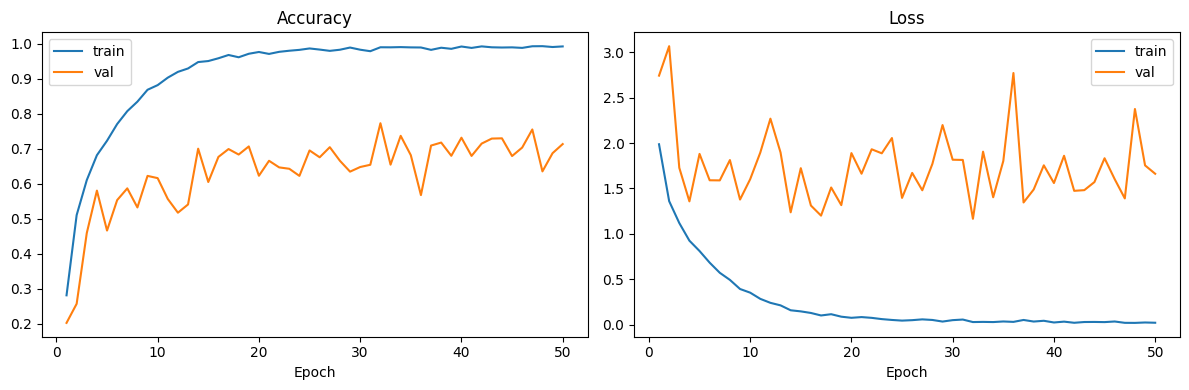

In [19]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

model = GTZANCNNBaseline(num_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
history = []

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for mels, labels_batch in tqdm(train_loader, desc=f'Epoch {epoch + 1}/{NUM_EPOCHS} train'):
        mels = mels.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()
        logits = model(mels)
        loss = criterion(logits, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * mels.size(0)
        preds = logits.argmax(dim=1)
        train_correct += (preds == labels_batch).sum().item()
        train_total += mels.size(0)

    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for mels, labels_batch in test_loader:
            mels = mels.to(device)
            labels_batch = labels_batch.to(device)
            logits = model(mels)
            loss = criterion(logits, labels_batch)
            val_loss += loss.item() * mels.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels_batch).sum().item()
            val_total += mels.size(0)

    train_loss /= train_total
    val_loss /= val_total
    train_acc = train_correct / train_total
    val_acc = val_correct / val_total

    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc,
    })
    print(
        f'Epoch {epoch + 1}/{NUM_EPOCHS} | '
        f'train loss {train_loss:.4f} acc {train_acc:.4f} | '
        f'val loss {val_loss:.4f} acc {val_acc:.4f}'
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f'  → saved {BEST_MODEL_PATH} (val acc {val_acc:.4f})')

history_df = pd.DataFrame(history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df['epoch'], history_df['train_acc'], label='train')
axes[0].plot(history_df['epoch'], history_df['val_acc'], label='val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].plot(history_df['epoch'], history_df['train_loss'], label='train')
axes[1].plot(history_df['epoch'], history_df['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

Test accuracy (best checkpoint): 0.7732
              precision    recall  f1-score   support

       blues       1.00      0.60      0.75       280
   classical       0.84      0.96      0.90       280
     country       0.74      0.75      0.74       280
       disco       0.68      0.63      0.66       280
      hiphop       0.79      0.91      0.84       280
        jazz       0.91      0.89      0.90       280
       metal       0.99      0.84      0.91       280
         pop       0.62      0.81      0.70       280
      reggae       0.88      0.65      0.75       280
        rock       0.54      0.70      0.61       280

    accuracy                           0.77      2800
   macro avg       0.80      0.77      0.78      2800
weighted avg       0.80      0.77      0.78      2800



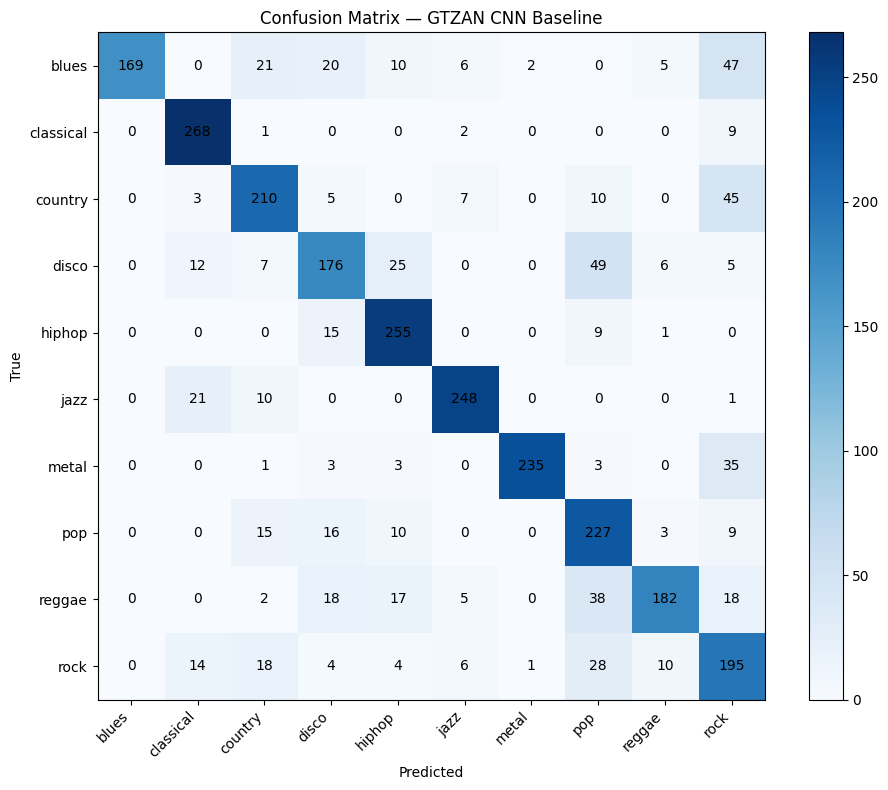

Results saved to checkpoints/gtzan_cnn_baseline_results.json


In [20]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

all_preds = []
all_labels = []
with torch.no_grad():
    for mels, labels_batch in test_loader:
        mels = mels.to(device)
        logits = model(mels)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc = (all_preds == all_labels).mean()

print(f'Test accuracy (best checkpoint): {test_acc:.4f}')
print(classification_report(all_labels, all_preds, target_names=genres))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(num_classes), genres, rotation=45, ha='right')
ax.set_yticks(range(num_classes), genres)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — GTZAN CNN Baseline')
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

results = {
    'test_accuracy': float(test_acc),
    'best_val_accuracy': float(best_val_acc),
    'num_train_segments': int(len(train_df)),
    'num_test_segments': int(len(test_df)),
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'target_shape': list(TARGET_SHAPE),
    'segment_length_sec': SEGMENT_LENGTH,
    'overlap_sec': OVERLAP,
    'sample_rate': SAMPLE_RATE,
}
RESULTS_JSON.write_text(json.dumps(results, indent=2))
print(f'Results saved to {RESULTS_JSON}')